# Etapa 1 — Análisis Exploratorio de Datos (EDA) + Modelo MLP Base

**Proyecto Final — Deep Learning | Maestría en Ciencia de Datos**

**Objetivo**: Seleccionar y documentar el dataset, realizar un EDA completo y entrenar un Perceptrón Multicapa (MLP) como modelo base de referencia.

**Dataset**: Defectos en superficies de aeronaves — 5 clases: crack, dent, scratch, missing_head, paint_off

---

## 1. Setup e Importaciones

In [1]:
import sys
import os
from pathlib import Path
from collections import Counter

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from glob import glob

import torch
import torch.nn as nn
from torchvision import transforms

from src.data_utils import (
    download_datasets, prepare_datasets, create_splits,
    get_dataloaders, compute_dataset_stats, get_class_distribution,
    get_class_weights, DefectDataset, CLASS_NAMES, NUM_CLASSES,
    DATA_DIR, RAW_DIR, PROCESSED_DIR, SPLITS_DIR,
    get_grayscale_flat_transforms, get_transforms,
)
from src.models import MLPClassifier, count_parameters
from src.train import train_classifier
from src.evaluate import (
    compute_metrics, get_predictions_with_proba,
    plot_confusion_matrix, plot_training_history,
    plot_roc_curves, plot_class_distribution, plot_sample_images,
)

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("viridis")
plt.rcParams["figure.dpi"] = 120

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

FIGURES_DIR = PROJECT_ROOT / "results" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"PyTorch: {torch.__version__}")
print(f"Device: {DEVICE}")
print(f"Project root: {PROJECT_ROOT}")
print(f"Clases: {CLASS_NAMES}")

PyTorch: 2.9.0+cu126
Device: cuda
Project root: d:\Documents\Maestria\ML\aircraft-skin-defect-classifier
Clases: ['crack', 'dent', 'missing_head', 'paint_off', 'scratch']


## 2. Descarga de Datos desde Roboflow

Se descargan dos datasets complementarios con las mismas 5 clases de defectos:
1. **aircraft-skin-defects-merged-final** (~2k imágenes) — Dibya Dillip
2. **aircraft-skin-defects** (~4.6k imágenes) — AI Assistant for Visual Inspection

> **Nota**: Necesitas una API key de Roboflow. Regístrate gratis en [roboflow.com](https://roboflow.com) y copia tu API key. Crea un archivo `.env` en la raíz del proyecto con `ROBOFLOW_API_KEY=tu_api_key`. Este archivo está en `.gitignore` y **nunca** se sube al repositorio.

In [2]:
from dotenv import load_dotenv
load_dotenv(PROJECT_ROOT / ".env")

API_KEY = os.environ.get("ROBOFLOW_API_KEY")
if not API_KEY:
    raise EnvironmentError(
        "Variable de entorno ROBOFLOW_API_KEY no configurada.\n"
        "Crea un archivo .env en la raiz del proyecto con:\n"
        "  ROBOFLOW_API_KEY=tu_api_key_aqui"
    )

if not RAW_DIR.exists() or len(list(RAW_DIR.iterdir())) == 0:
    print("Descargando datasets desde Roboflow...")
    download_datasets(api_key=API_KEY)
else:
    print(f"Datos ya descargados en {RAW_DIR}")
    for d in sorted(RAW_DIR.iterdir()):
        print(f"  {d.name}")

Datos ya descargados en D:\Documents\Maestria\ML\aircraft-skin-defect-classifier\data\raw
  dataset1
  dataset2


## 3. Preparación de Datos

Transformamos los datasets de **Object Detection** (bounding boxes) a **Clasificación de Imágenes** (parches recortados por clase). Cada bounding box se recorta generando un parche individual que se almacena en una carpeta por clase.

In [3]:
if not PROCESSED_DIR.exists() or len(list(PROCESSED_DIR.iterdir())) == 0:
    print("Procesando datasets (recortando bounding boxes)...")
    total_counts = prepare_datasets()
else:
    print("Datos ya procesados:")
    for cls_dir in sorted(PROCESSED_DIR.iterdir()):
        if cls_dir.is_dir():
            n = len(list(cls_dir.glob("*.jpg")))
            print(f"  {cls_dir.name}: {n} parches")

Datos ya procesados:
  crack: 8095 parches
  dent: 10064 parches
  missing_head: 7510 parches
  paint_off: 6731 parches
  scratch: 1501 parches


In [4]:
if not SPLITS_DIR.exists() or not (SPLITS_DIR / "train.csv").exists():
    print("Creando splits estratificados...")
    train_df, val_df, test_df = create_splits()
else:
    train_df = pd.read_csv(SPLITS_DIR / "train.csv")
    val_df = pd.read_csv(SPLITS_DIR / "val.csv")
    test_df = pd.read_csv(SPLITS_DIR / "test.csv")
    print(f"Splits cargados: train={len(train_df)}, val={len(val_df)}, test={len(test_df)}")

print(f"\nDistribucion total: {len(train_df) + len(val_df) + len(test_df)} imagenes")
print(f"  Train: {len(train_df)} ({len(train_df)/(len(train_df)+len(val_df)+len(test_df))*100:.1f}%)")
print(f"  Val:   {len(val_df)} ({len(val_df)/(len(train_df)+len(val_df)+len(test_df))*100:.1f}%)")
print(f"  Test:  {len(test_df)} ({len(test_df)/(len(train_df)+len(val_df)+len(test_df))*100:.1f}%)")

Splits cargados: train=23730, val=5085, test=5086

Distribucion total: 33901 imagenes
  Train: 23730 (70.0%)
  Val:   5085 (15.0%)
  Test:  5086 (15.0%)


## 4. Análisis Exploratorio de Datos (EDA)

### 4.1 Distribución de Clases

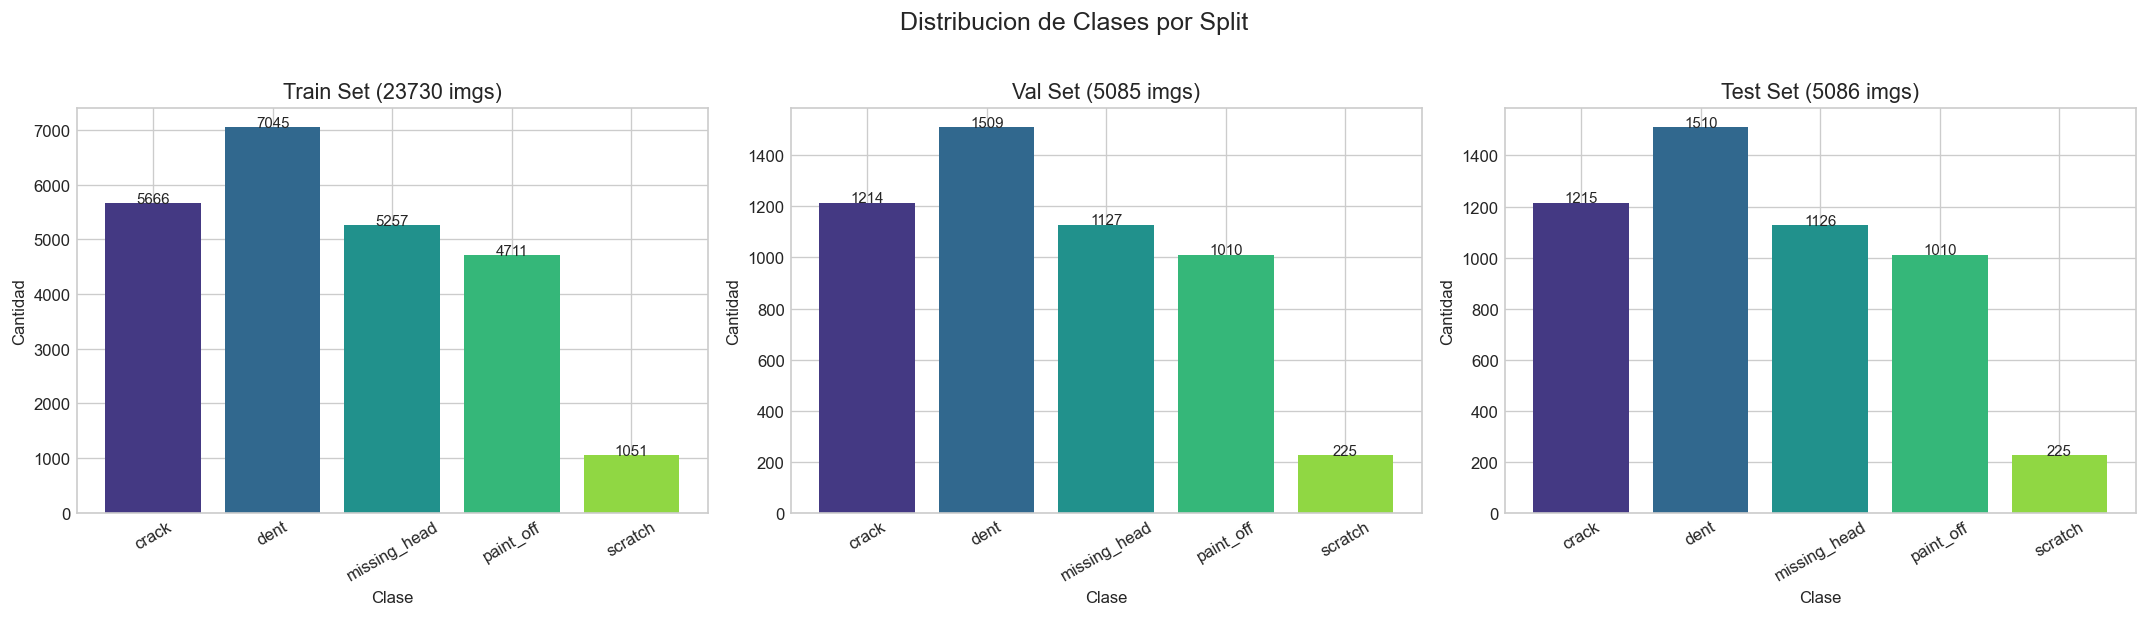


Ratio de desbalance (max/min): 6.70x
Clase mayoritaria: dent (7045)
Clase minoritaria: scratch (1051)


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, df) in zip(axes, [("Train", train_df), ("Val", val_df), ("Test", test_df)]):
    dist = df["label"].value_counts().sort_index()
    colors = sns.color_palette("viridis", len(dist))
    bars = ax.bar(dist.index, dist.values, color=colors)
    ax.set_title(f"{name} Set ({len(df)} imgs)", fontsize=13)
    ax.set_xlabel("Clase")
    ax.set_ylabel("Cantidad")
    ax.tick_params(axis="x", rotation=30)
    for bar, val in zip(bars, dist.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                str(val), ha="center", fontsize=9)

plt.suptitle("Distribucion de Clases por Split", fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

train_dist = train_df["label"].value_counts()
print(f"\nRatio de desbalance (max/min): {train_dist.max() / train_dist.min():.2f}x")
print(f"Clase mayoritaria: {train_dist.idxmax()} ({train_dist.max()})")
print(f"Clase minoritaria: {train_dist.idxmin()} ({train_dist.min()})")

### 4.2 Muestras de Imágenes por Clase

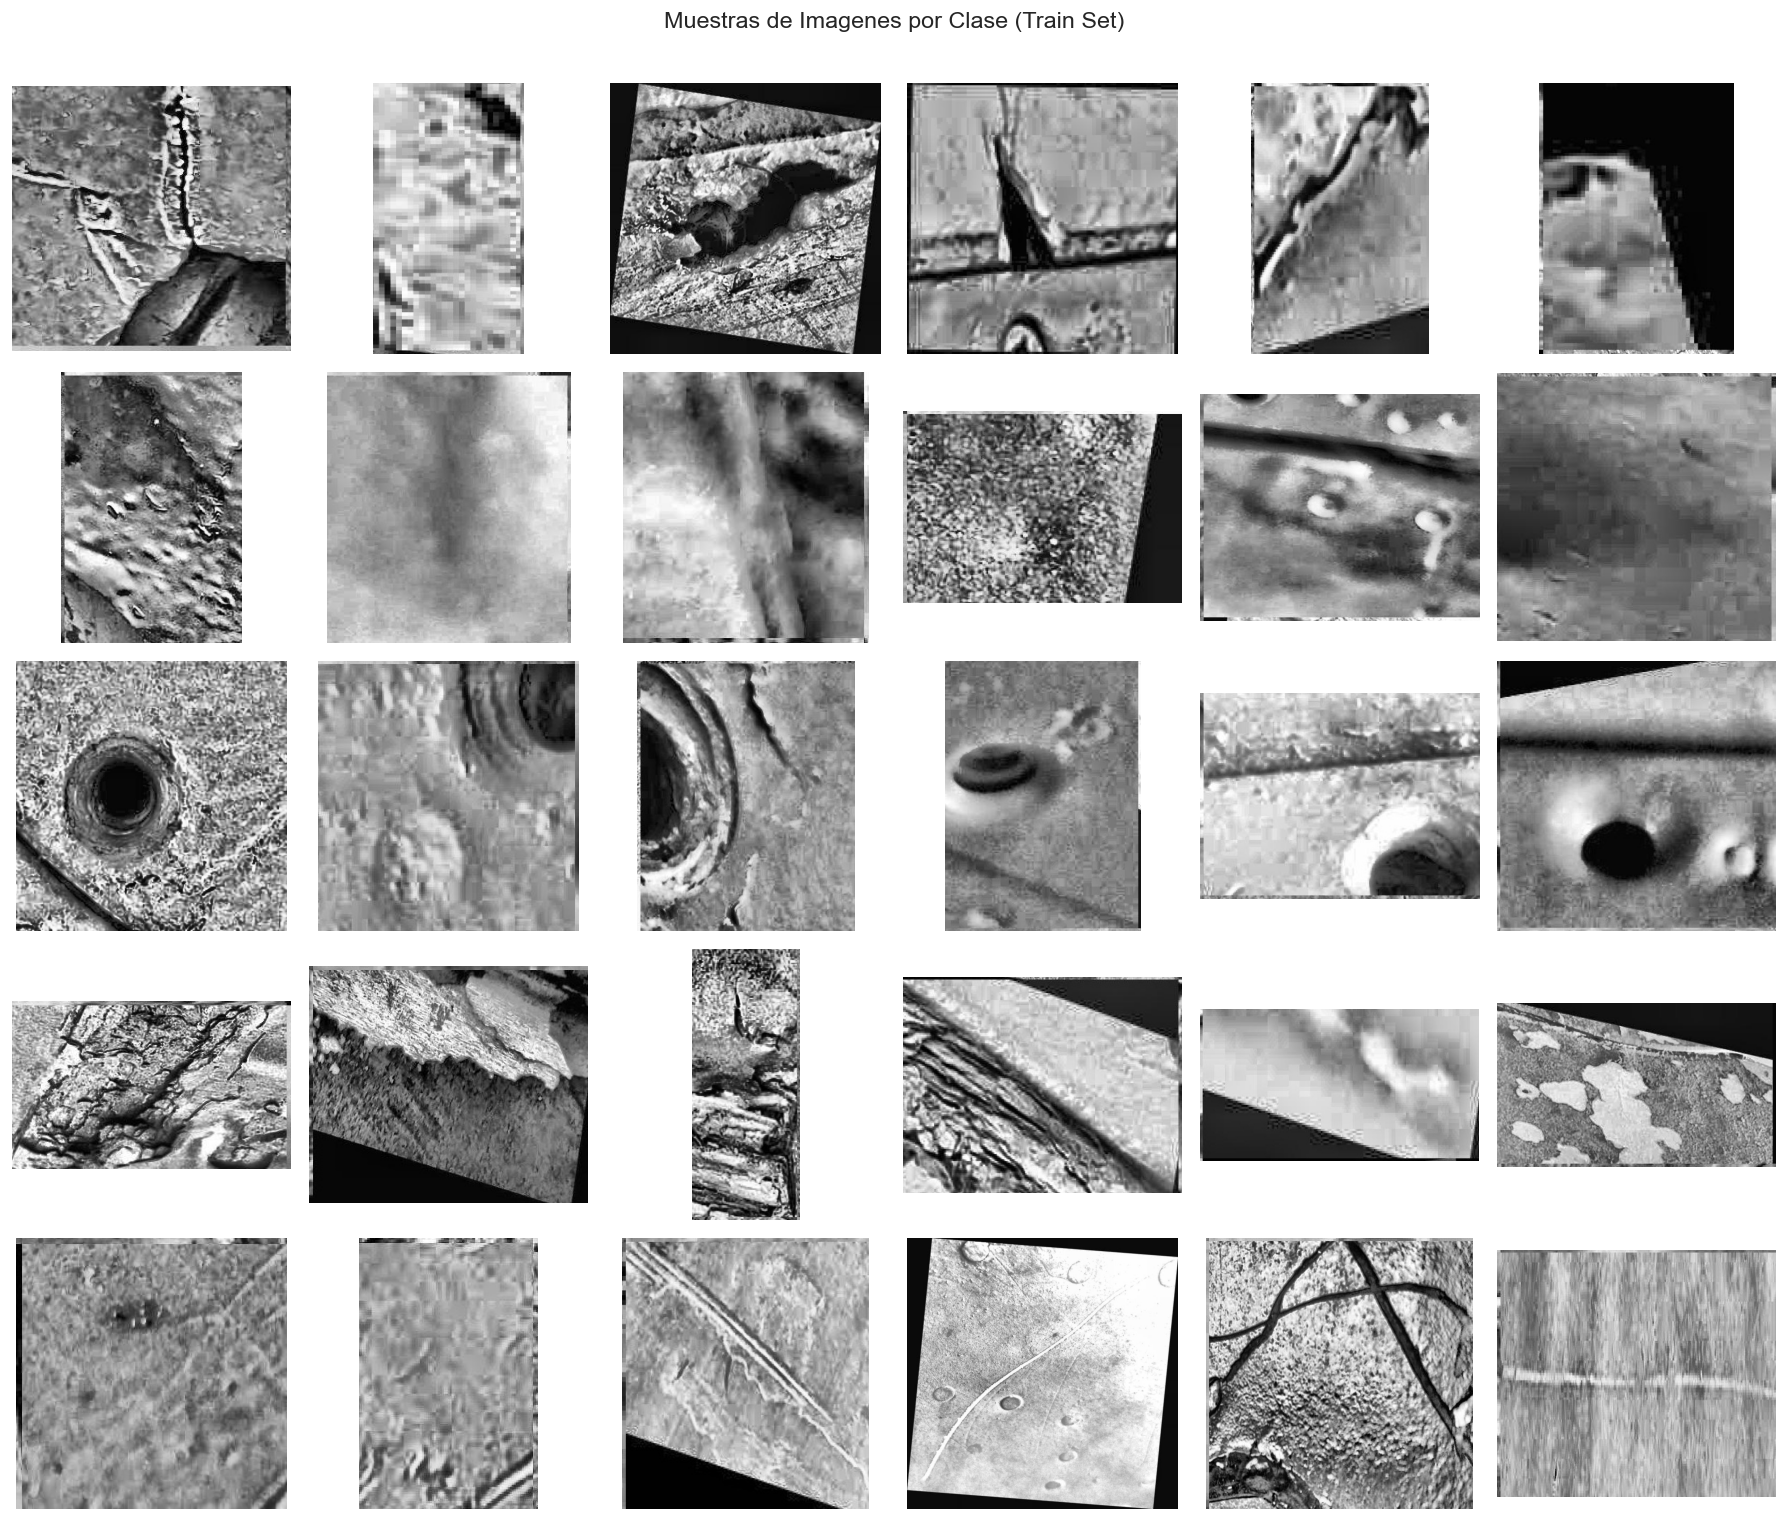

In [6]:
n_per_class = 6
fig, axes = plt.subplots(NUM_CLASSES, n_per_class, figsize=(n_per_class * 2.5, NUM_CLASSES * 2.5))

for i, cls_name in enumerate(CLASS_NAMES):
    cls_df = train_df[train_df["label"] == cls_name]
    samples = cls_df.sample(min(n_per_class, len(cls_df)), random_state=SEED)
    
    for j in range(n_per_class):
        ax = axes[i][j]
        if j < len(samples):
            img = Image.open(samples.iloc[j]["path"])
            ax.imshow(img)
            if j == 0:
                ax.set_ylabel(cls_name, rotation=0, labelpad=70, fontsize=11, va="center", fontweight="bold")
        ax.axis("off")

plt.suptitle("Muestras de Imagenes por Clase (Train Set)", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_sample_images.png", dpi=150, bbox_inches="tight")
plt.show()

### 4.3 Distribución de Tamaños de Parches

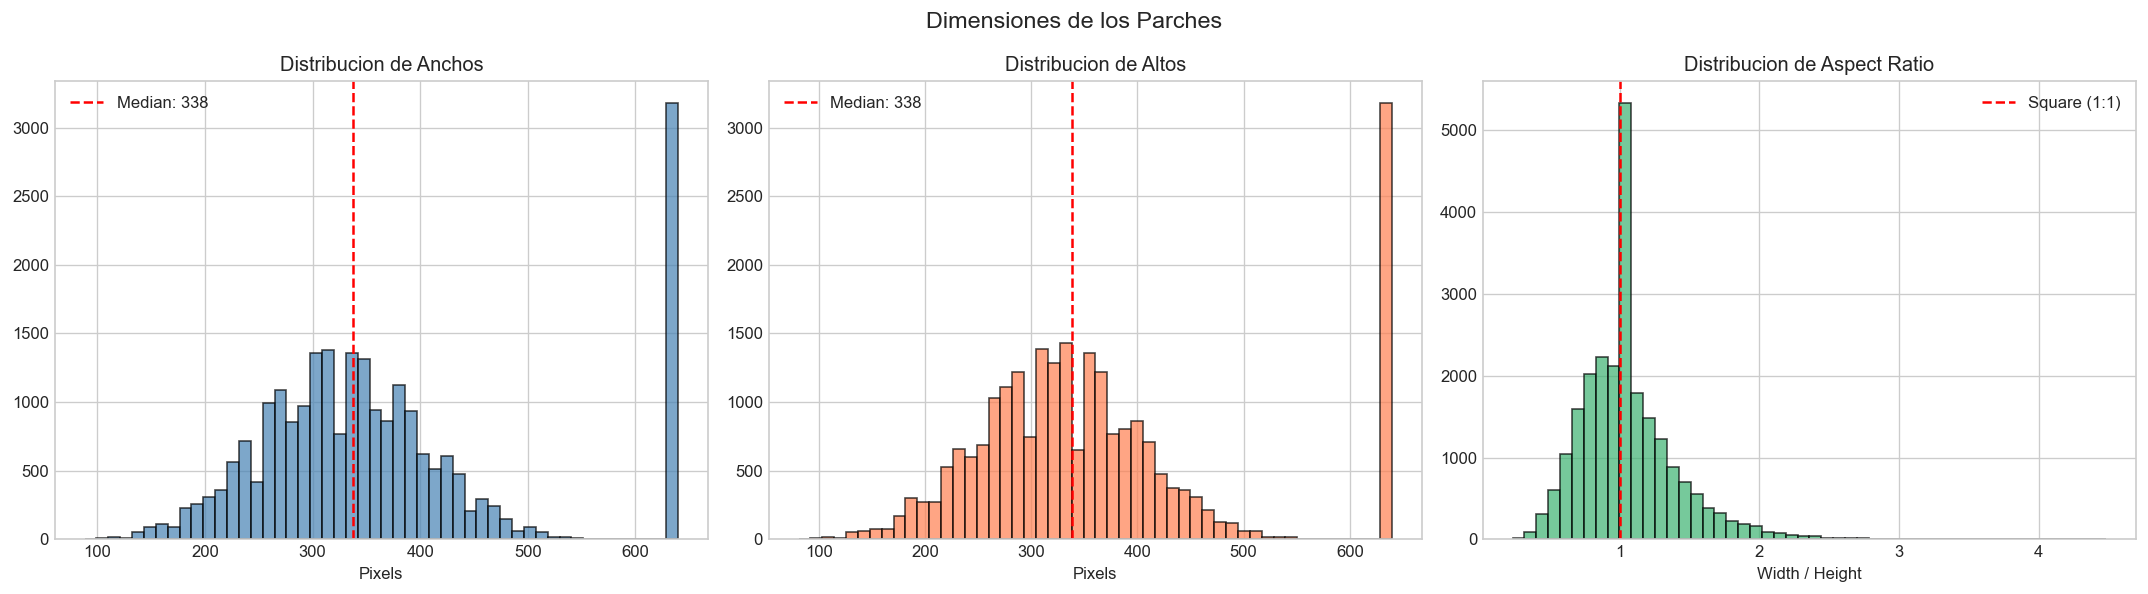

Dimensiones (WxH): mediana=338x338, media=368x367, min=88x81, max=640x640


In [7]:
widths, heights, aspects = [], [], []
class_sizes = {cn: {"w": [], "h": []} for cn in CLASS_NAMES}

for _, row in train_df.iterrows():
    img = Image.open(row["path"])
    w, h = img.size
    widths.append(w)
    heights.append(h)
    aspects.append(w / h if h > 0 else 1)
    class_sizes[row["label"]]["w"].append(w)
    class_sizes[row["label"]]["h"].append(h)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(widths, bins=50, color="steelblue", alpha=0.7, edgecolor="black")
axes[0].axvline(np.median(widths), color="red", linestyle="--", label=f"Median: {np.median(widths):.0f}")
axes[0].set_title("Distribucion de Anchos")
axes[0].set_xlabel("Pixels")
axes[0].legend()

axes[1].hist(heights, bins=50, color="coral", alpha=0.7, edgecolor="black")
axes[1].axvline(np.median(heights), color="red", linestyle="--", label=f"Median: {np.median(heights):.0f}")
axes[1].set_title("Distribucion de Altos")
axes[1].set_xlabel("Pixels")
axes[1].legend()

axes[2].hist(aspects, bins=50, color="mediumseagreen", alpha=0.7, edgecolor="black")
axes[2].axvline(1.0, color="red", linestyle="--", label="Square (1:1)")
axes[2].set_title("Distribucion de Aspect Ratio")
axes[2].set_xlabel("Width / Height")
axes[2].legend()

plt.suptitle("Dimensiones de los Parches", fontsize=14)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_patch_sizes.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Dimensiones (WxH): mediana={np.median(widths):.0f}x{np.median(heights):.0f}, "
      f"media={np.mean(widths):.0f}x{np.mean(heights):.0f}, "
      f"min={min(widths)}x{min(heights)}, max={max(widths)}x{max(heights)}")

### 4.4 Estadísticas de Píxeles (Media y Desviación Estándar por Canal)

In [8]:
                                                            print("Calculando estadisticas de pixeles del train set (puede tardar)...")
mean, std = compute_dataset_stats(SPLITS_DIR / "train.csv", img_size=224)
print(f"\nMedia por canal (R, G, B): {[f'{m:.4f}' for m in mean]}")
print(f"Std por canal  (R, G, B): {[f'{s:.4f}' for s in std]}")
print(f"\nComparacion con ImageNet: mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]")

Calculando estadisticas de pixeles del train set (puede tardar)...

Media por canal (R, G, B): ['0.5263', '0.5263', '0.5263']
Std por canal  (R, G, B): ['0.2444', '0.2444', '0.2444']

Comparacion con ImageNet: mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]


### 4.5 Análisis de Desbalance de Clases

El desbalance de clases es un aspecto crítico en este problema. Las imágenes de defectos raros (como `missing_head` o `paint_off`) son naturalmente menos frecuentes. Esto justificará la **generación de datos sintéticos** en la Etapa 4.

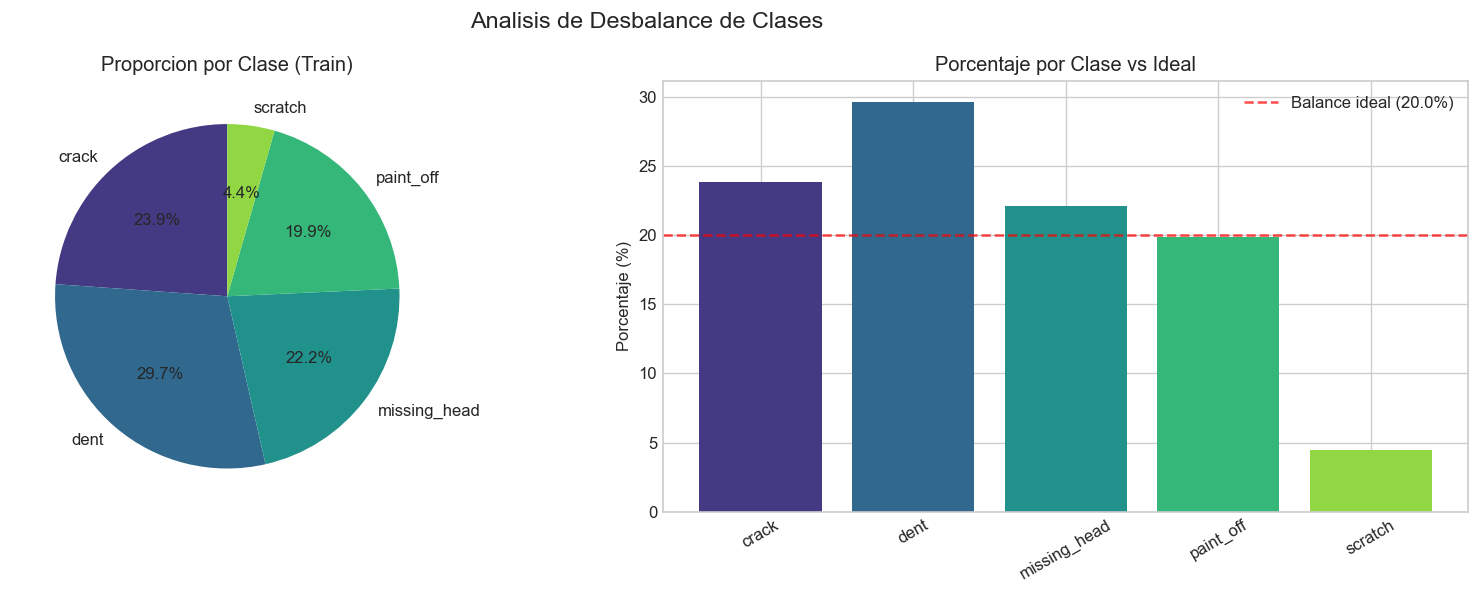

Pesos de clase (inversamente proporcionales a frecuencia):
  crack: 0.8376
  dent: 0.6737
  missing_head: 0.9028
  paint_off: 1.0074
  scratch: 4.5157


In [9]:
train_dist = train_df["label"].value_counts().sort_index()
total = train_dist.sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].pie(train_dist.values, labels=train_dist.index, autopct="%1.1f%%",
            colors=sns.color_palette("viridis", NUM_CLASSES), startangle=90)
axes[0].set_title("Proporcion por Clase (Train)")

bars = axes[1].bar(train_dist.index, train_dist.values / total * 100,
                   color=sns.color_palette("viridis", NUM_CLASSES))
axes[1].axhline(y=100/NUM_CLASSES, color="red", linestyle="--", alpha=0.7,
                label=f"Balance ideal ({100/NUM_CLASSES:.1f}%)")
axes[1].set_ylabel("Porcentaje (%)")
axes[1].set_title("Porcentaje por Clase vs Ideal")
axes[1].tick_params(axis="x", rotation=30)
axes[1].legend()

plt.suptitle("Analisis de Desbalance de Clases", fontsize=14)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_class_imbalance.png", dpi=150, bbox_inches="tight")
plt.show()

weights = get_class_weights(SPLITS_DIR / "train.csv")
print("Pesos de clase (inversamente proporcionales a frecuencia):")
for cn, w in zip(CLASS_NAMES, weights):
    print(f"  {cn}: {w:.4f}")

## 5. Modelo MLP Base

### 5.1 Preparación de DataLoaders

Para el MLP, las imágenes se convierten a **escala de grises** y se **aplanan** a un vector 1D de dimensión 128×128 = 16,384.

In [10]:
IMG_SIZE_MLP = 128
BATCH_SIZE = 32

train_loader, val_loader, test_loader = get_dataloaders(
    splits_dir=SPLITS_DIR,
    img_size=IMG_SIZE_MLP,
    batch_size=BATCH_SIZE,
    num_workers=0,
    augment_train=False,
    flatten_grayscale=True,
)

batch_x, batch_y = next(iter(train_loader))
print(f"Batch shape: {batch_x.shape}")
print(f"Labels shape: {batch_y.shape}")
print(f"Labels sample: {batch_y[:8]}")

Batch shape: torch.Size([32, 16384])
Labels shape: torch.Size([32])
Labels sample: tensor([0, 3, 4, 2, 2, 0, 1, 3])


### 5.2 Definición y Entrenamiento del MLP

In [11]:
mlp_model = MLPClassifier(
    input_dim=IMG_SIZE_MLP * IMG_SIZE_MLP,
    num_classes=NUM_CLASSES,
    dropout=0.3,
)

params = count_parameters(mlp_model)
print("=== Arquitectura MLP ===")
print(mlp_model)
print(f"\nParametros totales: {params['total']:,}")
print(f"Parametros entrenables: {params['trainable']:,}")

class_weights = get_class_weights(SPLITS_DIR / "train.csv")
print(f"\nPesos de clase: {dict(zip(CLASS_NAMES, class_weights.tolist()))}")

=== Arquitectura MLP ===
MLPClassifier(
  (net): Sequential(
    (0): Linear(in_features=16384, out_features=512, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): ReLU()
    (6): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=256, out_features=128, bias=True)
    (9): ReLU()
    (10): Dropout(p=0.15, inplace=False)
    (11): Linear(in_features=128, out_features=5, bias=True)
  )
)

Parametros totales: 8,555,525
Parametros entrenables: 8,555,525

Pesos de clase: {'crack': 0.8376279473304749, 'dent': 0.6736692786216736, 'missing_head': 0.9027962684631348, 'paint_off': 1.0074293613433838, 'scratch': 4.51569938659668}


In [12]:
print("Entrenando MLP Base...")
print(f"Device: {DEVICE}")
print(f"Epochs: 30, LR: 1e-3, Patience: 7\n")

mlp_history = train_classifier(
    model=mlp_model,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=30,
    lr=1e-3,
    weight_decay=1e-4,
    class_weights=class_weights,
    device=str(DEVICE),
    save_dir=PROJECT_ROOT / "results" / "models",
    model_name="mlp_base",
    patience=7,
    scheduler_type="plateau",
)

print(f"\nMejor val_acc: {mlp_history['best_val_acc']:.4f}")

Entrenando MLP Base...
Device: cuda
Epochs: 30, LR: 1e-3, Patience: 7



Epoch   1/30 | Train Loss: 1.4895 Acc: 0.3057 | Val Loss: 1.3982 Acc: 0.3479 | LR: 1.00e-03 | 446.4s
  Mejor modelo guardado (val_acc=0.3479)


Epoch   2/30 | Train Loss: 1.3787 Acc: 0.3620 | Val Loss: 1.3468 Acc: 0.3982 | LR: 1.00e-03 | 157.3s
  Mejor modelo guardado (val_acc=0.3982)


Epoch   3/30 | Train Loss: 1.3045 Acc: 0.3965 | Val Loss: 1.3269 Acc: 0.4140 | LR: 1.00e-03 | 155.1s
  Mejor modelo guardado (val_acc=0.4140)


Epoch   4/30 | Train Loss: 1.2376 Acc: 0.4214 | Val Loss: 1.3320 Acc: 0.3943 | LR: 1.00e-03 | 154.7s


...

Epoch  26/30 | Train Loss: 0.5339 Acc: 0.7537 | Val Loss: 2.0217 Acc: 0.4861 | LR: 3.13e-05 | 152.1s
  Mejor modelo guardado (val_acc=0.4861)


Epoch  27/30 | Train Loss: 0.5244 Acc: 0.7582 | Val Loss: 2.1086 Acc: 0.4916 | LR: 3.13e-05 | 152.2s
  Mejor modelo guardado (val_acc=0.4916)


Epoch  28/30 | Train Loss: 0.5246 Acc: 0.7575 | Val Loss: 2.0757 Acc: 0.4826 | LR: 1.56e-05 | 152.4s


Epoch  29/30 | Train Loss: 0.5273 Acc: 0.7596 | Val Loss: 2.0626 Acc: 0.4875 | LR: 1.56e-05 | 153.1s


Epoch  30/30 | Train Loss: 0.5205 Acc: 0.7622 | Val Loss: 2.0430 Acc: 0.4930 | LR: 1.56e-05 | 173.1s
  Mejor modelo guardado (val_acc=0.4930)

Mejor val_acc: 0.4930


## 6. Evaluación del MLP

### 6.1 Curvas de Entrenamiento

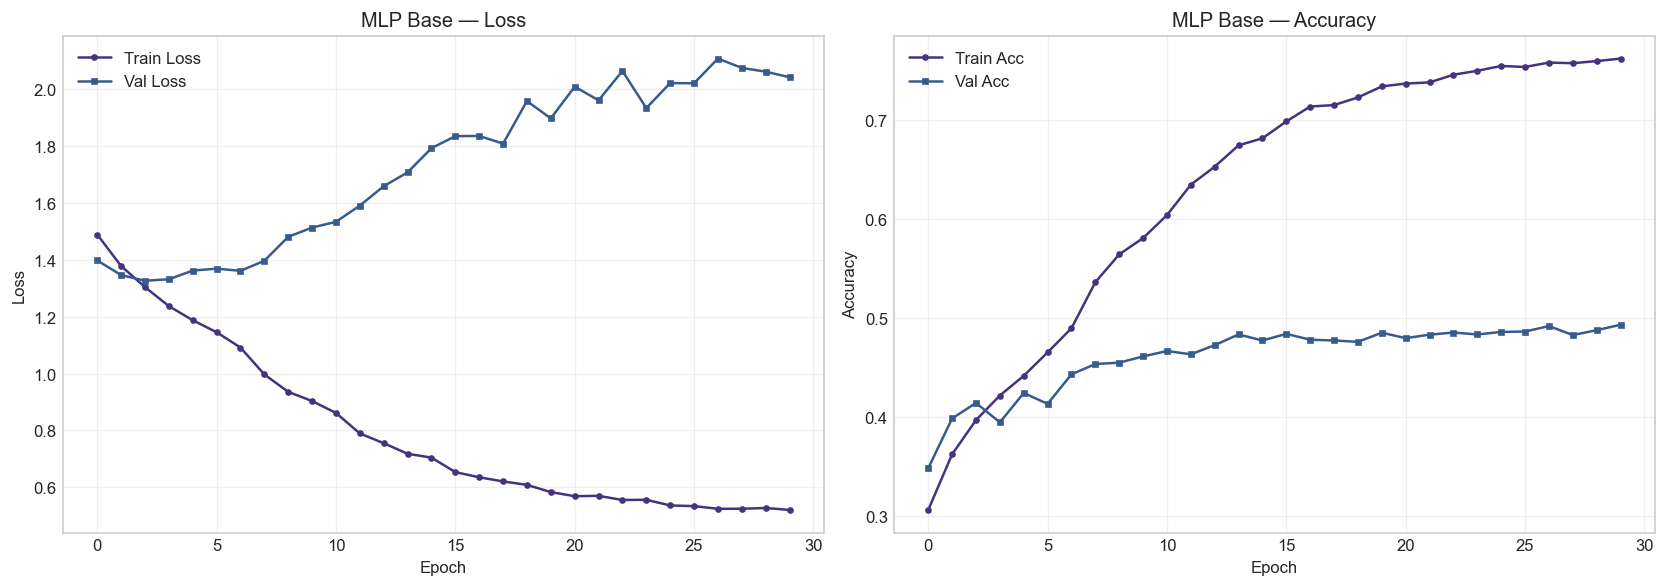

In [13]:
plot_training_history(mlp_history, title="MLP Base", save_path=FIGURES_DIR / "01_mlp_training.png")

### 6.2 Métricas en Test Set

In [ ]:
_true, y_pred, y_proba = get_predictions_with_proba(mlp_model, test_loader, DEVICE)
mlp_metrics = compute_metrics(y_true, y_pred, CLASS_NAMES, y_proba)

print("=" * 60)
print("RESULTADOS MLP BASE -- TEST SET")
print("=" * 60)
print(f"\nAccuracy:        {mlp_metrics['accuracy']:.4f}")
print(f"F1-Macro:        {mlp_metrics['f1_macro']:.4f}")
print(f"F1-Weighted:     {mlp_metrics['f1_weighted']:.4f}")
print(f"Precision-Macro: {mlp_metrics['precision_macro']:.4f}")
print(f"Recall-Macro:    {mlp_metrics['recall_macro']:.4f}")
if 'roc_auc_macro' in mlp_metrics:
    print(f"ROC-AUC Macro:   {mlp_metrics['roc_auc_macro']:.4f}")

print(f"\nF1 por clase:")
for cn, f1 in mlp_metrics["f1_per_class"].items():
    print(f"  {cn}: {f1:.4f}")

print(f"\n{mlp_metrics['classification_report']}")

RESULTADOS MLP BASE -- TEST SET

Accuracy:        0.4797
F1-Macro:        0.4548
F1-Weighted:     0.4817
Precision-Macro: 0.4514
Recall-Macro:    0.4614
ROC-AUC Macro:   0.7509

F1 por clase:
  crack: 0.4012
  dent: 0.5189
  missing_head: 0.6535
  paint_off: 0.3635
  scratch: 0.3372

              precision    recall  f1-score   support

       crack       0.41      0.39      0.40      1215
        dent       0.51      0.53      0.52      1510
missing_head       0.68      0.63      0.65      1126
   paint_off       0.36      0.37      0.36      1010
     scratch       0.30      0.39      0.34       225

    accuracy                           0.48      5086
   macro avg       0.45      0.46      0.45      5086
weighted avg       0.48      0.48      0.48      5086



### 6.3 Matriz de Confusión

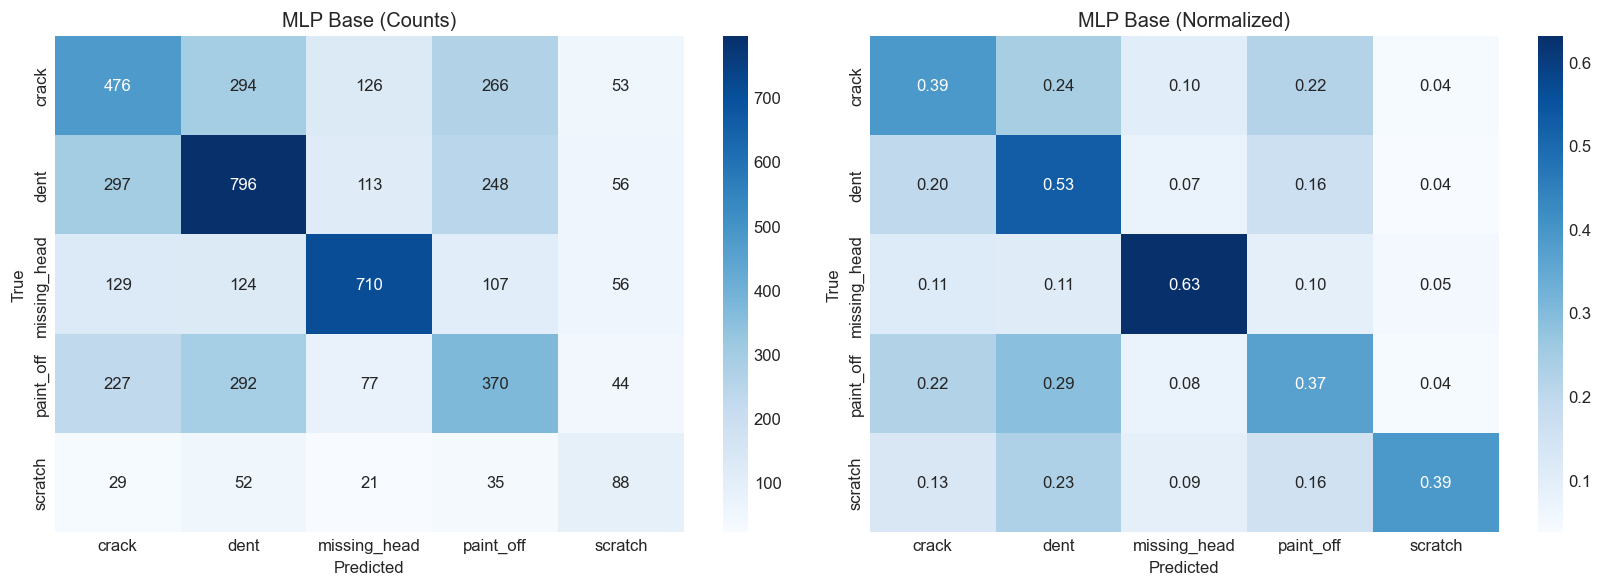

In [15]:
plot_confusion_matrix(
    y_true, y_pred, CLASS_NAMES,
    title="MLP Base",
    save_path=FIGURES_DIR / "01_mlp_confusion_matrix.png"
)

### 6.4 Curvas ROC

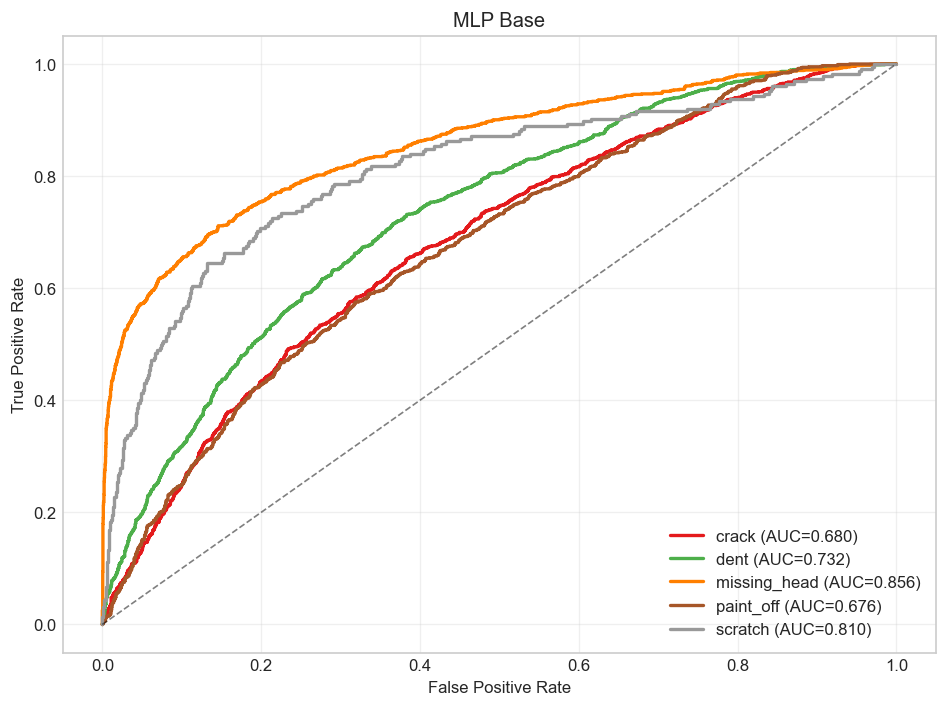

In [16]:
plot_roc_curves(
    y_true, y_proba, CLASS_NAMES,
    title="MLP Base",
    save_path=FIGURES_DIR / "01_mlp_roc_curves.png"
)

## 7. Guardar Modelo y Resultados

In [17]:
import json

model_path = PROJECT_ROOT / "results" / "models" / "mlp_base_final.pth"
model_path.parent.mkdir(parents=True, exist_ok=True)
torch.save({
    'model_state_dict': mlp_model.state_dict(),
    'class_names': CLASS_NAMES,
    'metrics': mlp_metrics,
    'history': mlp_history,
}, model_path)
print(f"Modelo guardado en {model_path}")

metrics_path = PROJECT_ROOT / "results" / "models" / "mlp_base_metrics.json"
metrics_json = {k: (float(v) if isinstance(v, (int, float, np.floating)) else v) for k, v in mlp_metrics.items() if k != 'classification_report'}
with open(metrics_path, 'w') as f:
    json.dump(metrics_json, f, indent=2, default=str)
print(f"Metricas guardadas en {metrics_path}")

Modelo guardado en d:\Documents\Maestria\ML\aircraft-skin-defect-classifier\results\models\mlp_base_final.pth
Metricas guardadas en d:\Documents\Maestria\ML\aircraft-skin-defect-classifier\results\models\mlp_base_metrics.json


## 8. Resumen y Conclusiones

### Hallazgos del EDA
- Se recopilaron imágenes de defectos de piel de aeronaves de múltiples datasets de Roboflow
- Las 5 clases objetivo (crack, dent, missing_head, paint_off, scratch) presentan desbalance moderado
- Las imágenes recortadas (patches) varían en tamaño, justificando el redimensionamiento a tamaño fijo

### Resultados del MLP Base
- El MLP sirve como **línea base** (baseline) para comparar con modelos más sofisticados
- **Limitación principal**: Al aplanar la imagen, se pierde toda la información espacial/estructural
- Se espera un accuracy moderado-bajo dado que los defectos son patrones visuales que requieren entender estructura local
- Este resultado justifica el uso de **CNNs** en la Etapa 2, que preservan la estructura espacial

### Próximos pasos
- **Etapa 2**: CNN profunda desde cero con ablation study
- **Etapa 3**: Transfer learning con ResNet50 y Vision Transformer (ViT)
- **Etapa 4**: Componente generativo (VAE + Conditional GAN) para data augmentation
- **Etapa 5**: Fine-tuning con LoRA/PEFT, cuantización, pruning y despliegue con Gradio